In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import random

In [4]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [5]:
# Load the dataset
df = pd.read_csv(r'C:\Users\GOWTHAM\Downloads\python\electricityConsumptionAndProductioction.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

In [6]:
# Normalize the data
scaler = MinMaxScaler()
data_columns = ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
scaled_data = scaler.fit_transform(df[data_columns])

In [7]:
# Feature Engineering: Add rolling and lag features for better temporal dependencies
df['Consumption_RollingMean'] = df['Consumption'].rolling(window=3).mean().fillna(method='bfill')
df['Consumption_Lag1'] = df['Consumption'].shift(1).fillna(method='bfill')

C:\Users\GOWTHAM\AppData\Local\Temp\ipykernel_19056\3079764677.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Consumption_RollingMean'] = df['Consumption'].rolling(window=3).mean().fillna(method='bfill')
C:\Users\GOWTHAM\AppData\Local\Temp\ipykernel_19056\3079764677.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Consumption_Lag1'] = df['Consumption'].shift(1).fillna(method='bfill')


In [8]:
# Updated columns for scaling
data_columns += ['Consumption_RollingMean', 'Consumption_Lag1']
scaled_data = scaler.fit_transform(df[data_columns])


In [9]:
# Create sequences for RNN
SEQ_LENGTH = 24  # Predict next step based on last 24 hours
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        seq = data[i:i + seq_length]
        label = data[i + seq_length, 0]  # Predicting 'Consumption'
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

sequences, labels = create_sequences(scaled_data, SEQ_LENGTH)

In [10]:
# Train-test split
split_ratio = 0.8
split_index = int(len(sequences) * split_ratio)
X_train, X_test = sequences[:split_index], sequences[split_index:]
y_train, y_test = labels[:split_index], labels[split_index:]

In [11]:
# Define custom loss with Entropy Regularization
def entropy_regularizer(y_true, y_pred):
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))  # Standard MSE loss
    entropy = -tf.reduce_mean(y_pred * tf.math.log(y_pred + 1e-8))  # Entropy term
    return mse_loss + 0.01 * entropy  # Entropy Regularization

In [12]:
# Build the RNN model with regularization
rnn_model = Sequential([
    SimpleRNN(256, return_sequences=True, input_shape=(SEQ_LENGTH, X_train.shape[2]), activation='relu'),
    Dropout(0.3),
    SimpleRNN(128, return_sequences=False, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='relu')  # Output prediction
])

d:\Python\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# Compile the model
rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss=entropy_regularizer)

In [14]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

In [15]:
# Train the model
history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,  # Adjusted to 20%
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - loss: 0.0252 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 2/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - loss: 0.0078 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 3/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0063 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 4/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - loss: 0.0056 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 5/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - loss: 0.0051 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 6/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - loss: 0.0048 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 7/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - loss: 0.0045 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 8/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0045 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 9/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 0.0042 - val_loss: 0.0041 - learning_rate:

In [16]:
# Predict
predictions = rnn_model.predict(X_test)

288/288 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [18]:
# Rescale predictions
y_test_rescaled = scaler.inverse_transform(np.concatenate([y_test.reshape(-1, 1), np.zeros((len(y_test), len(data_columns) - 1))], axis=1))[:, 0]
predictions_rescaled = scaler.inverse_transform(np.concatenate([predictions, np.zeros((len(predictions), len(data_columns) - 1))], axis=1))[:, 0]

In [19]:
# Evaluation metrics
r2 = r2_score(y_test_rescaled, predictions_rescaled)
mae = mean_absolute_error(y_test_rescaled, predictions_rescaled)
mse = mean_squared_error(y_test_rescaled, predictions_rescaled)
rmse = np.sqrt(mse)

print(f"RNN Model - R² Score: {r2:.4f}")
print(f"RNN Model - Mean Absolute Error (MAE): {mae:.4f}")
print(f"RNN Model - Mean Squared Error (MSE): {mse:.4f}")
print(f"RNN Model - Root Mean Squared Error (RMSE): {rmse:.4f}")

RNN Model - R² Score: 0.9710
RNN Model - Mean Absolute Error (MAE): 125.6486
RNN Model - Mean Squared Error (MSE): 25378.8552
RNN Model - Root Mean Squared Error (RMSE): 159.3074


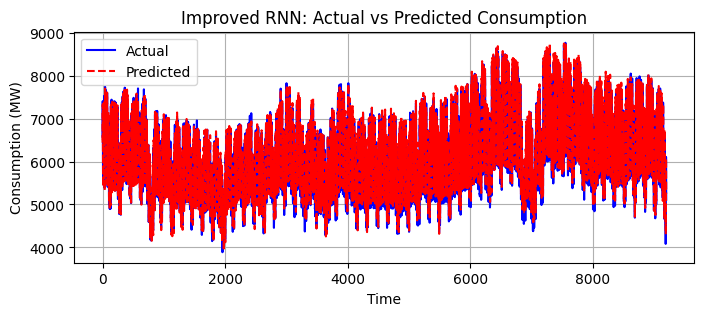

In [21]:
# Visualization
plt.figure(figsize=(8, 3))
plt.plot(y_test_rescaled, label='Actual', color='blue')
plt.plot(predictions_rescaled, label='Predicted', color='red', linestyle='dashed')
plt.title('Improved RNN: Actual vs Predicted Consumption')
plt.xlabel('Time')
plt.ylabel('Consumption (MW)')
plt.legend()
plt.grid()
plt.show()

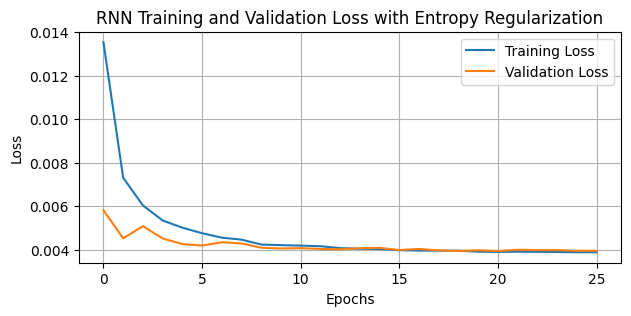

In [22]:
# Training and validation loss
plt.figure(figsize=(7, 3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss with Entropy Regularization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()